# Gene prioritization by link probabilities
---

In [21]:
import os
import pandas as pd
import pickle
from CADA.triples_gene_hpo import triples_gene_hpo
import networkx as nx
import numpy as np
from CADA.gae.preprocessing import mask_test_edges
from gensim.models import Word2Vec
from CADA.paths import DATA_DIRECTORY,MODEL_DIRECTORY

In [22]:
# Collect only gene-hpo term edges
gene_hpo_triples = triples_gene_hpo()
gene_hpo_edges = []
for triple in gene_hpo_triples:
    gene_hpo_edges.append((triple[0], triple[2]))
g_gene_hpo_edges = nx.Graph()
g_gene_hpo_edges.add_edges_from(gene_hpo_edges)
adj_sparse_gene_hpo_edges = nx.to_scipy_sparse_matrix(g_gene_hpo_edges)

# record gene nodes
nodes = list(g_gene_hpo_edges.nodes())
nodes_gene = []
for node in nodes:
    if node.startswith("Entrez:"):
        nodes_gene.append(node)

In [23]:
import numpy as np
from CADA.gae.preprocessing import mask_test_edges

In [24]:
np.random.seed(0)
adj_train, train_edges, train_edges_false, val_edges, val_edges_false, \
    test_edges, test_edges_false = mask_test_edges(adj_sparse_gene_hpo_edges, test_frac=.0, val_frac=.0, prevent_disconnect=False, verbose=True)
g_gene_hpo_edges_train = nx.from_scipy_sparse_matrix(adj_train) # new graph object with only non-hidden edges


preprocessing...
generating test/val sets...
creating false test edges...
creating false val edges...
creating false train edges...
final checks for disjointness...
creating adj_train...
Done with train-test split!



In [25]:
# Inspect train/test split
print(f'The number of gene-hpo term edges: {len(g_gene_hpo_edges.edges())}')
print(f'Training edges (positive): {len(train_edges)}')
print(f'Training edges (negative): {len(train_edges_false)}')
print(f'Validation edges (positive): {len(val_edges)}')
print(f'Validation edges (negative): {len(val_edges_false)}')
print(f'Test edges (positive): {len(test_edges)}')
print(f'Test edges (negative): {len(test_edges_false)}')

The number of gene-hpo term edges: 169281
Training edges (positive): 169281
Training edges (negative): 169281
Validation edges (positive): 0
Validation edges (negative): 0
Test edges (positive): 0
Test edges (negative): 0


In [28]:
# get embeddings and create node embeddings matrix(rows = nodes, columns = embedding features)
model = Word2Vec.load('node2vec.model')
emb_mappings = model.wv
emb_list = []
for node in g_gene_hpo_edges.nodes():
    node_emb = emb_mappings[node]
    emb_list.append(node_emb)
emb_matrix = np.vstack(emb_list)

In [29]:
# Generate bootstrapped edge embeddings (as is done in node2vec paper)
# Edge embedding for (v1, v2) = hadamard product of node embeddings for v1, v2
def get_edge_embeddings(edge_list):
    embs = []
    for edge in edge_list:
        node1 = edge[0]
        node2 = edge[1]
        emb1 = emb_matrix[node1]
        emb2 = emb_matrix[node2]
        edge_emb = np.multiply(emb1, emb2)
        embs.append(edge_emb)
    embs = np.array(embs)
    return embs

In [46]:
# Train-set edge embeddings, labels: 1 = real edge, 0 = false edge
pos_train_edge_embs = get_edge_embeddings(train_edges)
neg_train_edge_embs = get_edge_embeddings(train_edges_false)
train_edge_embs = np.concatenate([pos_train_edge_embs, neg_train_edge_embs])
train_edge_labels = np.concatenate([np.ones(len(train_edges)), np.zeros(len(train_edges_false))])

In [47]:
# Train logistic regression classifier on train-set edge embeddings
from sklearn.linear_model import LogisticRegression
edge_classifier = LogisticRegression(random_state=0)
edge_classifier.fit(train_edge_embs, train_edge_labels)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=0, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [48]:
#count the number of training patients with a specific mutation for each mutation gene
train = os.path.join(os.getcwd(), 'patient_training.tsv')
if os.path.exists(train):
    train_pd = pd.read_csv(train, header=None, sep='\t', names=['patient_id', 'omim_id', 'gene_id', 'features', 'submitter',
                                    'from_file', 'no_features'])
    gene_counts = train_pd['gene_id'].value_counts().to_dict() 
else:
    gene_counts = {}

In [49]:
with open(os.path.join(DATA_DIRECTORY, 'processed', 'ids', 'gene_id_name.dict'), 'rb') as handle:
    gene_id_name = pickle.load(handle)

with open(os.path.join(DATA_DIRECTORY, 'processed', 'ids', 'hpo_id_name.dict'), 'rb') as handle:
    hpo_id_name = pickle.load(handle)

In [50]:
dir_name = 'phen2gene'
if os.path.exists(dir_name):
    print("Directory '%s' exist" %dir_name)
else:
    os.mkdir('phen2gene')
    print("Directory '%s' created" %dir_name)

Directory 'phen2gene' exist


In [53]:
## Prioritizing genes for each test patient based on their hpo terms
test_patients = pd.read_csv('patient_testing.tsv', sep = '\t', header=None)
evaluation_save = list()
evaluation_vis = list()

for patient in test_patients.values.tolist():
    prioritized_genelist = []
    patient_id = patient[0]
    patient_name = patient[0].split(':')[1]
    gene_id = patient[2]
    target_gene = patient[2].split(':')[1]
    
    # Get the number training patients with same mutation gene
    if gene_id in gene_counts:
        no_patients = gene_counts[gene_id]
    else:
        no_patients = 0
    # Get result from phen2gene
    phen2gene_result_path = os.path.join(dir_name, 'out', dir_name, patient_name, 'output_file.associated_gene_list')
    phen2gene_result_pd = pd.read_csv(phen2gene_result_path, sep = '\t', header = 0, dtype = str)
    
    try:
        rank_phen2gene = int(phen2gene_result_pd.loc[phen2gene_result_pd['ID'] == target_gene, 'Rank'].iloc[0])
    except IndexError:
        rank_phen2gene = 'NA'
        
    # prioritize genes for each patients by taking the max function of probalities to patient's hpo terms
    features = patient[3].split(',')
    table_prob = {}
    table_dot_aver = {}
    table_dot_max = {}
    
    for gene in nodes_gene:
        sc_scores = [] 
        edge_embs = []
        gene_emb = model.wv[gene]
        for feature in features:
            feature_emb = model.wv[feature]
            edge_emb = np.multiply(feature_emb, gene_emb)
            edge_embs.append(edge_emb)
            sc_score = np.dot(feature_emb, gene_emb)
            sc_scores.append(sc_score)
        prob = sum((edge_classifier.predict_proba(edge_embs)[:, 1]).tolist())
        table_prob[gene] = prob
        table_dot_aver[gene] = sum(sc_scores)
        table_dot_max[gene] = max(sc_scores) 
    prioritized_genes_prob = pd.DataFrame.from_dict(table_prob, orient='index', columns=['score']).sort_values(by='score', ascending=False).index.values.tolist()
    prioritized_genes_dot_aver = pd.DataFrame.from_dict(table_dot_aver, orient='index', columns=['score']).sort_values(by='score', ascending=False).index.values.tolist()
    prioritized_genes_dot_max = pd.DataFrame.from_dict(table_dot_max, orient='index', columns=['score']).sort_values(by='score', ascending=False).index.values.tolist()
    # get the rank
    if gene_id in prioritized_genes_prob:
        rank_prob = prioritized_genes_prob.index(gene_id) + 1
    else:
        rank_prob = 'NA'
    if gene_id in prioritized_genes_dot_aver:
        rank_dot_aver = prioritized_genes_dot_aver.index(gene_id) + 1
    else:
        rank_dot_aver = 'NA'
    if gene_id in prioritized_genes_dot_max:
        rank_dot_max = prioritized_genes_dot_max.index(gene_id) + 1
    else:
        rank_dot_max = 'NA'
    
    evaluation_save.append([patient_id, gene_id, no_patients,','.join(features), rank_prob, rank_dot_aver, rank_dot_max, rank_phen2gene])
    evaluation_vis.append([patient_id, gene_id_name[gene_id], no_patients,
                                   ','.join([hpo_id_name[feature] for feature in features]), rank_prob, rank_dot_aver, rank_dot_max, rank_phen2gene])

                

In [56]:
# save the result
saveframe = pd.DataFrame(evaluation_save, columns = ['patient_id', 'gene_id','no_patients', 'features', 'rank_prob', 'rank_dot_aver', 'rank_dot_max', 'rank_phen2gene'])
saveframe.to_csv('evaluation.tsv', sep='\t', index=None)
visframe = pd.DataFrame(evaluation_vis, columns=['patient_id', 'gene', 'no_patients', 'features', 'rank_prob', 'rank_dot_aver', 'rank_dot_max', 'rank_phen2gene'])
visframe.to_excel('evaluation.xlsx', index=None) 
                

In [76]:
ranks_prob = saveframe['rank_prob'].tolist()
ranks_dot_aver = saveframe['rank_dot_aver'].tolist()
ranks_dot_max = saveframe['rank_dot_max'].tolist()
ranks_phe2gene = saveframe['rank_phen2gene'].tolist()
counts = len(ranks_prob)

top1_prob = round(len([i for i in ranks_prob if isinstance(i, int) and i == 1])/counts, 3) 
top5_prob = round(len([i for i in ranks_prob if isinstance(i, int) and i <= 5])/counts, 3) 
top10_prob = round(len([i for i in ranks_prob if isinstance(i, int) and i <= 10])/counts, 3) 
top50_prob = round(len([i for i in ranks_prob if isinstance(i, int) and i <= 50])/counts, 3) 
top100_prob = round(len([i for i in ranks_prob if isinstance(i, int) and i <= 100])/counts, 3) 
top1000_prob = round(len([i for i in ranks_prob if isinstance(i, int) and i <= 1000])/counts, 3) 

top1_dot_aver = round(len([i for i in ranks_dot_aver if isinstance(i, int) and i == 1])/counts, 3) 
top5_dot_aver = round(len([i for i in ranks_dot_aver if isinstance(i, int) and i <= 5])/counts, 3) 
top10_dot_aver = round(len([i for i in ranks_dot_aver if isinstance(i, int) and i <= 10])/counts, 3) 
top50_dot_aver = round(len([i for i in ranks_dot_aver if isinstance(i, int) and i <= 50])/counts, 3)
top100_dot_aver = round(len([i for i in ranks_dot_aver if isinstance(i, int) and i <= 100])/counts, 3)
top1000_dot_aver = round(len([i for i in ranks_dot_aver if isinstance(i, int) and i <= 1000])/counts, 3)

top1_dot_max = round(len([i for i in ranks_dot_max if isinstance(i, int) and i == 1])/counts, 3)
top5_dot_max = round(len([i for i in ranks_dot_max if isinstance(i, int) and i <= 5])/counts, 3)
top10_dot_max = round(len([i for i in ranks_dot_max if isinstance(i, int) and i <= 10])/counts, 3) 
top50_dot_max = round(len([i for i in ranks_dot_max if isinstance(i, int) and i <= 50])/counts, 3)
top100_dot_max = round(len([i for i in ranks_dot_max if isinstance(i, int) and i <= 100])/counts, 3)
top1000_dot_max = round(len([i for i in ranks_dot_max if isinstance(i, int) and i <= 1000])/counts, 3)

top1_phe2gene = round(len([i for i in ranks_phe2gene if isinstance(i, int) and i == 1])/counts, 3)
top5_phe2gene = round(len([i for i in ranks_phe2gene if isinstance(i, int) and i <= 5])/counts, 3)
top10_phe2gene = round(len([i for i in ranks_phe2gene if isinstance(i, int) and i <= 10])/counts, 3)
top50_phe2gene = round(len([i for i in ranks_phe2gene if isinstance(i, int) and i <= 50])/counts, 3)
top100_phe2gene = round(len([i for i in ranks_phe2gene if isinstance(i, int) and i <= 100])/counts, 3)
top1000_phe2gene = round(len([i for i in ranks_phe2gene if isinstance(i, int) and i <= 1000])/counts, 3)


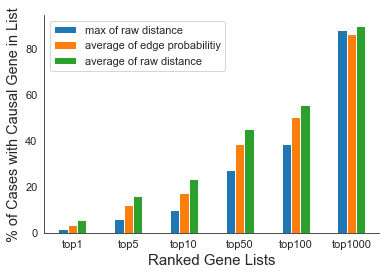

In [103]:
sns.set_style('white')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.size'] = 11

index = ['top1', 'top5', 'top10', 'top50', 'top100', 'top1000']

values_prob = [round(i*100,1) for i in [top1_prob, top5_prob, top10_prob, top50_prob, top100_prob, top1000_prob]]
values_dot_aver = [round(i*100,1) for i in [top1_dot_aver, top5_dot_aver, top10_dot_aver, top50_dot_aver, top100_dot_aver, top1000_dot_aver]]
values_dot_max = [round(i*100,1) for i in [top1_dot_max, top5_dot_max, top10_dot_max, top50_dot_max, top100_dot_max, top1000_dot_max]]
values_phe2gene = [round(i*100,1) for i in [top1_phe2gene, top5_phe2gene, top10_phe2gene, top50_phe2gene, top100_phe2gene, top1000_phe2gene]]


df = pd.DataFrame({'max of raw distance': values_dot_max,
                   'average of edge probabilitiy': values_prob,
                   'average of raw distance': values_dot_aver}, index=index)
ax = df.plot.bar(rot=0)
ax.set_xlabel("Ranked Gene Lists", fontsize=15)
ax.set_ylabel("% of Cases with Causal Gene in List", fontsize=14.5)
sns.despine()

plt.savefig('figures/edge_emeb.png', bbox_inches='tight')

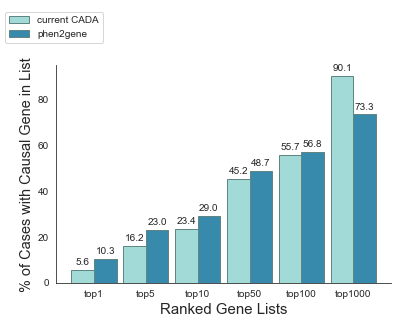

In [100]:
import seaborn as sns

sns.set_style('white')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.size'] = 10
fig, ax = plt.subplots(1)
width=1
distance = 2.3
lefts=np.arange(0,distance*len(index),distance)
rects=ax.bar(x=lefts,height=values_dot_aver,width=width,color=(161/255.0,218/255.0,215/255.0), edgecolor=(96/255.0, 133/255.0, 131/255.0),label='current CADA')
autolabel(rects)

alefts=np.arange(0+width,distance*len(index)+width, distance)
rects=ax.bar(x=alefts,height=values_phe2gene,width=width,tick_label=index,color=(56/255.0,138/255.0,172/255.0),edgecolor=(96/255.0, 133/255.0, 131/255.0),label='phen2gene')

ax.set_xticks(alefts-width*.5)

autolabel(rects)

fig.legend(loc='upper left', ncol=1,bbox_to_anchor=(0, 1.1))



def mkdir_p(path):
    import os
    if not os.path.isdir(path):
        os.makedirs(path)



ax.set_xlabel("Ranked Gene Lists", fontsize=15)

ax.set_ylabel("% of Cases with Causal Gene in List", fontsize=14.5)

sns.despine()


plt.savefig('figures/compare_phen2gene.png', bbox_inches='tight')

In [105]:
# count median rank for patients of each gene
gene_rank = saveframe.groupby('gene_id')[['rank_dot_aver']].median().sort_values(by='rank_dot_aver')
gene_rank.columns = ['median_rank']
gene_rank

,median_rank
gene_id,
Entrez:5961,1.0
Entrez:3914,1.0
Entrez:392255,1.0
Entrez:7020,1.0
Entrez:60495,1.0
...,...
Entrez:23476,4178.0
Entrez:9493,4201.0
Entrez:2068,4238.0


In [106]:
gene_analysis = pd.read_csv('../descriptive_statistics/genes_hpo_disease_patient.csv', sep = '\t', index_col=0)

In [109]:
gene_table = pd.merge(gene_analysis, gene_rank, left_index=True, right_index=True, how='outer')
gene_table[['num_hpo_annotation', 'num_disease', 'median_rank']]

,num_hpo_annotation,num_disease,median_rank
Entrez:10000,28,1.0,500.0
Entrez:10002,46,2.0,115.0
Entrez:1001,48,2.0,31.0
Entrez:100151683,224,2.0,1106.0
Entrez:10020,100,2.0,1986.0
...,...,...,...
Entrez:9968,279,3.0,103.0
Entrez:998,131,1.0,305.5
Entrez:999,68,6.0,27.0
Entrez:9990,58,1.0,341.0


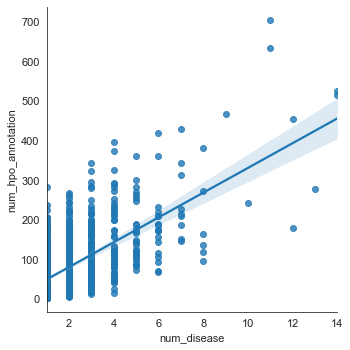

In [113]:
plot_num_hpo_num_disease = sns.lmplot(x='num_disease', y='num_hpo_annotation', data=gene_table, fit_reg=True)
plot_num_hpo_num_disease.savefig("figures/gene_numHPO_numDisease.png")

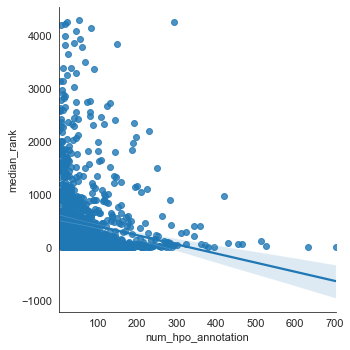

In [114]:
plot_num_hpo_median_rank = sns.lmplot(x='num_hpo_annotation', y='median_rank', data=gene_table, fit_reg=True)
plot_num_hpo_num_disease.savefig("figures/gene_numHPO_medianRank.png")